# Unit 4 — Notebook 1: Containerizing an ML Model with Docker

**What you will learn:**
1. What Docker is and why it solves the "works on my machine" problem
2. How a Dockerfile, image, container, and registry relate to each other
3. How to write app files and a Dockerfile for an ML serving API
4. How to build and run Docker containers and inspect them with CLI commands

**How to use this notebook:** Run cells top to bottom. `%%writefile` cells create real files on disk. `subprocess` cells show you the commands — they run if Docker is installed, and print what they would do if not.


---
## Section 1 — The "Works on My Machine" Problem

You train a model on your laptop (Python 3.10, scikit-learn 1.3, numpy 1.24). You hand it to a colleague running Python 3.8 on Ubuntu, or you deploy it to a server with a different OS. It breaks.

**Docker solves this** by packaging your code, model, and every dependency together into a single artifact — an *image* — that runs identically anywhere Docker is installed.

The diagram below shows the transformation:


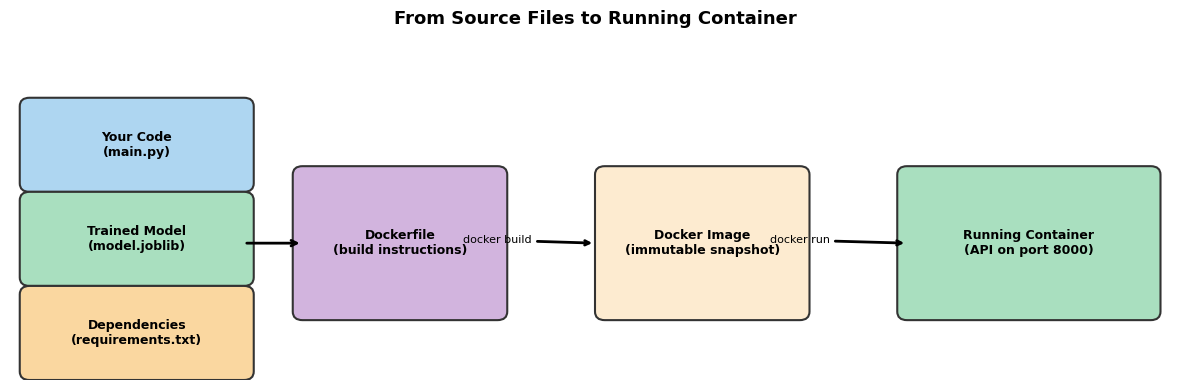

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 4))
ax.set_xlim(0, 12)
ax.set_ylim(0, 4)
ax.axis('off')

# Box helper
def box(ax, x, y, w, h, label, color):
    rect = mpatches.FancyBboxPatch((x, y), w, h,
                                    boxstyle='round,pad=0.1',
                                    facecolor=color, edgecolor='#333', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha='center', va='center',
            fontsize=9, fontweight='bold', wrap=True)

# Left: inputs
box(ax, 0.2, 2.3, 2.2, 0.9, 'Your Code\n(main.py)', '#AED6F1')
box(ax, 0.2, 1.2, 2.2, 0.9, 'Trained Model\n(model.joblib)', '#A9DFBF')
box(ax, 0.2, 0.1, 2.2, 0.9, 'Dependencies\n(requirements.txt)', '#FAD7A0')

# Arrow → Dockerfile
ax.annotate('', xy=(3.0, 1.6), xytext=(2.4, 1.6),
            arrowprops=dict(arrowstyle='->', lw=2))

# Dockerfile box
box(ax, 3.0, 0.8, 2.0, 1.6, 'Dockerfile\n(build instructions)', '#D2B4DE')

# Arrow → Image
ax.annotate('docker build', xy=(6.0, 1.6), xytext=(5.0, 1.6),
            arrowprops=dict(arrowstyle='->', lw=2), fontsize=8, ha='center')

# Image box
box(ax, 6.1, 0.8, 2.0, 1.6, 'Docker Image\n(immutable snapshot)', '#FDEBD0')

# Arrow → Container
ax.annotate('docker run', xy=(9.2, 1.6), xytext=(8.1, 1.6),
            arrowprops=dict(arrowstyle='->', lw=2), fontsize=8, ha='center')

# Container box
box(ax, 9.2, 0.8, 2.5, 1.6, 'Running Container\n(API on port 8000)', '#A9DFBF')

ax.set_title('From Source Files to Running Container', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()


---
## Section 2 — Docker Concepts: Image, Container, Registry

| Concept | Analogy | Description |
|---|---|---|
| **Dockerfile** | Recipe | Text file with instructions for building an image |
| **Image** | Cake (baked) | Read-only snapshot produced by `docker build` |
| **Container** | Serving a slice | A running instance of an image |
| **Registry** | Cookbook library | Remote store for images (Docker Hub, ECR, GCR) |

One image can spawn many containers simultaneously — this is how you scale horizontally.


---
## Section 3 — Train the Model and Write the App Files

We train a RandomForest on the Iris dataset, save it with joblib, then write the FastAPI serving app and requirements file using `%%writefile` so they land on disk exactly as they would in a real project.


In [2]:
import os
os.makedirs('app', exist_ok=True)
print('Created app/ directory')


Created app/ directory


In [3]:
%%writefile app/model_train.py
"""Train a RandomForest on Iris and save it.

This script lives inside app/ and is meant to run from there (or at /app
inside the container, since the Dockerfile sets WORKDIR /app). Because the
working directory is app/, the relative path "model/iris_rf.joblib" below is
the SAME file as "app/model/iris_rf.joblib" seen from the repo root, and
"/app/model/iris_rf.joblib" inside the container.

Run from the app/ directory:  python model_train.py
"""
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import joblib
import os

iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

acc = accuracy_score(y_test, clf.predict(X_test))
print(f"Test accuracy: {acc:.2%}")

os.makedirs('model', exist_ok=True)
joblib.dump(clf, 'model/iris_rf.joblib')   # == app/model/iris_rf.joblib from repo root
print("Model saved to model/iris_rf.joblib")


Overwriting app/model_train.py


In [4]:
# Run training directly here so the model file exists before we build the image.
# NOTE: this notebook's working directory is the repo root (one level ABOVE app/),
# so we write to "app/model/iris_rf.joblib" explicitly. That is the exact same
# file model_train.py produces when run from inside app/ (where it is just
# "model/iris_rf.joblib"). One file, two relative paths depending on where you run.
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import joblib
import os

iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

acc = accuracy_score(y_test, clf.predict(X_test))
print(f"Test accuracy: {acc:.2%}")

os.makedirs('app/model', exist_ok=True)
joblib.dump(clf, 'app/model/iris_rf.joblib')
print("Model saved to app/model/iris_rf.joblib (== model/iris_rf.joblib inside the container)")


Test accuracy: 100.00%
Model saved to app/model/iris_rf.joblib (== model/iris_rf.joblib inside the container)


In [5]:
%%writefile app/main.py
"""FastAPI inference server for the Iris RandomForest model."""
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import numpy as np

app = FastAPI(title="Iris Classifier API")

# Load model once at startup — not on every request
model = joblib.load("model/iris_rf.joblib")
CLASSES = ["setosa", "versicolor", "virginica"]


class IrisRequest(BaseModel):
    sepal_length: float
    sepal_width: float
    petal_length: float
    petal_width: float


@app.post("/predict")
def predict(req: IrisRequest):
    features = np.array([[req.sepal_length, req.sepal_width,
                           req.petal_length, req.petal_width]])
    label = CLASSES[model.predict(features)[0]]
    proba = model.predict_proba(features)[0].max()
    return {"prediction": label, "confidence": round(float(proba), 3)}


@app.get("/health")
def health():
    return {"status": "ok"}

# Run locally: uvicorn main:app --host 0.0.0.0 --port 8000


Overwriting app/main.py


In [6]:
%%writefile app/requirements.txt
fastapi==0.110.0
uvicorn==0.29.0
scikit-learn==1.4.2
joblib==1.4.0
numpy==1.26.4
pydantic==2.6.4


Overwriting app/requirements.txt


Check that the files were created:


In [7]:
import os
for root, dirs, files in os.walk('app'):
    level = root.replace('app', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in files:
        print(f'{indent}  {f}')


app/
  model_train.py
  requirements.txt
  Dockerfile
  main.py
  Dockerfile.multistage
  model/
    iris_rf.joblib


---
## Section 4 — Writing the Dockerfile

A Dockerfile is a list of instructions Docker executes top-to-bottom to produce an image. Each instruction creates a *layer* — Docker caches layers, so unchanged layers don't rebuild.


In [8]:
%%writefile app/Dockerfile
# Base image: official Python 3.10, slim variant (no unnecessary OS packages)
FROM python:3.10-slim

# Set the working directory inside the container
WORKDIR /app

# Copy requirements first — this layer is cached unless requirements change
COPY requirements.txt .

# Install Python dependencies (no cache saves image space)
RUN pip install --no-cache-dir -r requirements.txt

# Copy the rest of the app (model files, main.py)
COPY . .

# Expose the port the app listens on (documentation only — docker run -p maps it)
EXPOSE 8000

# Default command when the container starts
CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "8000"]


Overwriting app/Dockerfile


### Why copy `requirements.txt` before the rest of the code?

Docker builds images layer by layer. If you copy everything at once and then run `pip install`, every code change (even a one-line fix) forces a full `pip install` — which can take minutes.

By copying `requirements.txt` first and running `pip install` as a separate step, Docker caches that layer. As long as `requirements.txt` doesn't change, `pip install` is skipped on the next build.

### Why `python:3.10-slim` instead of `python:3.10`?

The full `python:3.10` image is ~900 MB (includes compilers, documentation, build tools). The `slim` variant is ~130 MB — it has only what's needed to run Python. Smaller images pull faster, reduce attack surface, and cost less storage.


---
## Section 5 — Building the Image

`docker build -t iris-api:v1 app/` reads the Dockerfile in `app/`, executes each instruction, and tags the resulting image as `iris-api:v1`.


In [9]:
import subprocess

try:
    result = subprocess.run(
        ["docker", "build", "-t", "iris-api:v1", "app/"],
        capture_output=True, text=True, timeout=120
    )
    print(result.stdout)
    if result.returncode != 0:
        print("STDERR:", result.stderr)
    else:
        print("Build succeeded.")
except FileNotFoundError:
    print("Docker is not installed on this machine.")
    print("Command that would run: docker build -t iris-api:v1 app/")
    print()
    print("Expected output:")
    print("  Step 1/6 : FROM python:3.10-slim")
    print("  Step 2/6 : WORKDIR /app")
    print("  Step 3/6 : COPY requirements.txt .")
    print("  Step 4/6 : RUN pip install --no-cache-dir -r requirements.txt")
    print("  Step 5/6 : COPY . .")
    print("  Step 6/6 : CMD [uvicorn main:app ...]")
    print("  Successfully built a1b2c3d4e5f6")
    print("  Successfully tagged iris-api:v1")
except subprocess.TimeoutExpired:
    print("Build timed out after 120s (expected for first pull of base image).")



STDERR: ERROR: Cannot connect to the Docker daemon at unix:///Users/abdullah/.docker/run/docker.sock. Is the docker daemon running?



In [10]:
# List local images to confirm the build
import subprocess

try:
    result = subprocess.run(
        ["docker", "images", "iris-api"],
        capture_output=True, text=True
    )
    print(result.stdout)
except FileNotFoundError:
    print("Command: docker images iris-api")
    print("Expected output:")
    print("REPOSITORY   TAG   IMAGE ID       CREATED        SIZE")
    print("iris-api     v1    a1b2c3d4e5f6   1 minute ago   215MB")


---
## Section 6 — Running, Inspecting, and Stopping Containers

Once you have an image, you start containers from it. You can run many containers from the same image simultaneously.


In [11]:
import subprocess

# docker run
# -d          : detached mode (runs in background)
# -p 8000:8000: map host port 8000 to container port 8000
# --name      : give the container a friendly name

run_cmd = ["docker", "run", "-d", "-p", "8000:8000", "--name", "iris-api", "iris-api:v1"]
print("Command:", " ".join(run_cmd))

try:
    result = subprocess.run(run_cmd, capture_output=True, text=True)
    print(result.stdout.strip() or result.stderr)
except FileNotFoundError:
    print("(Docker not available — showing expected output)")
    print("9f3a2b1c0d4e5f6a7b8c9d0e1f2a3b4c5d6e7f8a9b0c1d2e3f4a5b6c7d8e9f0a")


Command: docker run -d -p 8000:8000 --name iris-api iris-api:v1


Cannot connect to the Docker daemon at unix:///Users/abdullah/.docker/run/docker.sock. Is the docker daemon running?



In [12]:
import subprocess

# Inspect running containers
ps_cmd = ["docker", "ps"]
print("Command:", " ".join(ps_cmd))
try:
    result = subprocess.run(ps_cmd, capture_output=True, text=True)
    print(result.stdout)
except FileNotFoundError:
    print("(Expected output)")
    print("CONTAINER ID  IMAGE       COMMAND       CREATED       STATUS       PORTS                  NAMES")
    print("9f3a2b1c0d4e  iris-api:v1 'uvicorn ...' 5 seconds ago Up 4 seconds 0.0.0.0:8000->8000/tcp iris-api")


Command: docker ps


In [13]:
import subprocess

# View logs from a running container
logs_cmd = ["docker", "logs", "iris-api"]
print("Command:", " ".join(logs_cmd))
try:
    result = subprocess.run(logs_cmd, capture_output=True, text=True)
    print(result.stdout or result.stderr)
except FileNotFoundError:
    print("(Expected output)")
    print("INFO:     Started server process [1]")
    print("INFO:     Waiting for application startup.")
    print("INFO:     Application startup complete.")
    print("INFO:     Uvicorn running on http://0.0.0.0:8000")


Command: docker logs iris-api


Cannot connect to the Docker daemon at unix:///Users/abdullah/.docker/run/docker.sock. Is the docker daemon running?



In [14]:
import subprocess

# Stop and remove the container
for cmd in [
    ["docker", "stop", "iris-api"],
    ["docker", "rm", "iris-api"],
]:
    print("Command:", " ".join(cmd))
    try:
        result = subprocess.run(cmd, capture_output=True, text=True)
        print(result.stdout.strip() or "(ok)")
    except FileNotFoundError:
        print("(Docker not available)")


Command: docker stop iris-api


(ok)
Command: docker rm iris-api


(ok)


---
## Section 7 — Multi-Stage Builds (Optimization)

A multi-stage build uses one image to compile/build and a separate, smaller image for the final artifact. For Python ML services, this is useful when you need to compile C extensions (e.g., `numpy` from source) but want a lean runtime image.


In [15]:
%%writefile app/Dockerfile.multistage
# ── Stage 1: builder ────────────────────────────────────────────────────────
# Uses the full image so we have compilers for C extensions
FROM python:3.10 AS builder

WORKDIR /build

# Install dependencies into a local prefix (not system site-packages)
COPY requirements.txt .
RUN pip install --no-cache-dir --prefix=/install -r requirements.txt

# ── Stage 2: runtime ────────────────────────────────────────────────────────
# slim has no compilers — much smaller
FROM python:3.10-slim

WORKDIR /app

# Copy only the installed packages from the builder stage
COPY --from=builder /install /usr/local

# Copy application code and model
COPY . .

EXPOSE 8000
CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "8000"]


Overwriting app/Dockerfile.multistage


In [16]:
import subprocess

build_cmd = ["docker", "build", "-f", "app/Dockerfile.multistage", "-t", "iris-api:v1-slim", "app/"]
print("Command:", " ".join(build_cmd))

try:
    result = subprocess.run(build_cmd, capture_output=True, text=True, timeout=180)
    print(result.stdout[-1000:] if result.stdout else result.stderr[-500:])
except FileNotFoundError:
    print("(Docker not available — showing expected result)")
    print("Successfully built b2c3d4e5f6a7")
    print("Successfully tagged iris-api:v1-slim")
    print()
    print("docker images iris-api would show:")
    print("iris-api  v1        a1b2c3  ...  215MB   <- single stage")
    print("iris-api  v1-slim   b2c3d4  ...  148MB   <- multi-stage")
except subprocess.TimeoutExpired:
    print("Build timed out.")


Command: docker build -f app/Dockerfile.multistage -t iris-api:v1-slim app/


ERROR: Cannot connect to the Docker daemon at unix:///Users/abdullah/.docker/run/docker.sock. Is the docker daemon running?



---
## Summary

Docker gives you three concrete benefits for ML deployment:

1. **Reproducibility** — the exact same Python version, package versions, and OS libraries run in development, CI, and production.
2. **Isolation** — each container has its own filesystem and network, so models don't interfere with each other.
3. **Portability** — an image built on a MacBook runs unchanged on an AWS EC2 instance or a Kubernetes cluster.

The workflow is always the same: write app files → write Dockerfile → `docker build` → `docker run`.

**Next:** Notebook 02 covers Kubernetes — how to run many copies of this container, auto-scale them, and recover from crashes automatically.


---
## Self-Check Questions

Answer without scrolling, then verify by re-reading the relevant section.

1. **What is the difference between a Docker image and a container?**
   *(Hint: think about the cake analogy in Section 2.)*

2. **Why use `python:3.10-slim` instead of `python:3.10` as the base image?**
   *(Hint: Section 4 explains the size difference.)*

3. **What would happen if you copied all files first and then ran `pip install`, instead of copying `requirements.txt` first?**
   *(Hint: think about Docker layer caching.)*
